# Overall study on the different effects of the tilted crystal

There exist different types of interaction with the crystal for charged particles:

## Types of interaction of a tilted silicon crystal with a proton beam

When a high-energy proton beam crosses a **tilted silicon crystal**, different interaction regimes can occur depending on the **incident angle** of the proton with respect to the crystal planes and on the crystal geometry.

### 1. Channeling (CH)
If the proton enters the crystal with an angle smaller than the **critical angle** with respect to the crystal planes, it can be trapped between atomic planes and guided by the bent lattice.  
In a bent crystal, this produces a coherent deflection close to the **crystal bending angle**.

### 2. Dechanneling (DC)
A proton initially captured in the channeling regime can leave the channel because of scattering with electrons or nuclei inside the crystal.  
These particles are only partially steered and populate the region between the channeling peak and the amorphous component.

### 3. Volume Reflection (VR)
If the proton is not captured into channeling but crosses the region where the bent crystal planes change orientation, it can experience a coherent deflection in the direction opposite to the crystal bending.  
This effect usually gives a smaller angular kick than channeling, but it acts on a wider angular range.

### 4. Volume Capture (VC)
A proton that initially is not channeled can be scattered into a stable channel while traversing the crystal.  
After being captured, it follows the crystal curvature and contributes to the channeling-like deflection.

### 5. Amorphous scattering (AM)
If the proton does not undergo coherent interaction with the crystal planes, the crystal behaves approximately like an amorphous material.  
The proton then experiences mainly multiple Coulomb scattering, with no strong coherent deflection.

### 6. Nuclear interactions
A small fraction of protons can undergo inelastic or elastic interactions with crystal nuclei.  
These processes may lead to large-angle scattering, energy loss, or particle loss from the beam.

### Role of the crystal tilt
The **tilt angle** determines the orientation of the crystal planes seen by the incoming protons.  
By changing the tilt, one can move between regimes dominated by:
- **channeling**
- **dechanneling**
- **volume reflection**
- **volume capture**
- **amorphous scattering**

This is why the crystal tilt is a key parameter in the study of proton-crystal interactions.

In [1]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad


import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

import pandas as pd

# Make a context and get a buffer
context = xo.ContextCpu()         # For CPU
# context = xo.ContextCupy()      # For CUDA GPUs
# context = xo.ContextPyopencl()  # For OpenCL GPUs

In [2]:
num_part = int(10000)
x_init = 0.002 * np.ones(num_part)
px_init = np.zeros(num_part)
y_init   = np.zeros(num_part)
py_init  = np.zeros(num_part)

def initialize_particles(context, num_particles=num_part):
    return xp.Particles(
        _context=context,
        x=x_init,  
        px=px_init, 
        y=y_init,
        py=py_init,
        delta=0,
        p0c=4e11
    )
    

In [3]:
# Define the crystal properties (initial values)
length = 0.002
material = xc.materials.SiliconCrystal
bending_angle =  440e-6 / 5
width = 0.002
height = 0.05
side = '+'
miscut = 0.0
lattice = 'strip'
jaw = 0.001

In [4]:
# Dataframe to store particle tracking information
columns = ['iteration', 'particle_id', 'x', 'px']
tracking_data = pd.DataFrame(columns=columns)

In [5]:

min_angle = -100
max_angle = 100
steps = 1
# Define the range of bending angles to iterate over
impacting_angles = [i * 1e-6 for i in range(min_angle, max_angle, steps)]  # Example: 100 µrad to 200 µrad in 10 µrad steps


In [6]:

# List to collect all tracking data
tracking_data_list = []
critical_angle = 0

# Loop over bending angles
for iteration, angle in enumerate(impacting_angles):
    # Create the crystal with the current bending angle
    coll = xc.EverestCrystal(
        length=length,
        material=material,
        bending_angle=bending_angle,
        width=width,
        height=height,
        side=side,
        miscut=miscut,
        lattice=lattice,
        tilt = angle,    #IMPORTANT
        jaw=jaw,
        _context=context
    )
    
    # Initialize a new beam of particles for this iteration
    part = initialize_particles(context)
    part_init = part.copy()
    
    # Track particles through the crystal
    coll.track(part)  # Updates the particle states in place
    
    # Collect particle data for this iteration
    for i in range(len(part.x)):
        tracking_data_list.append({
            'iteration': iteration,
            'particle_id': i,
            'x': part.x[i],
            'px': part.px[i],
            'px_init': part_init.px[i],
            'angle': angle
        })
    print(str(iteration))
    #print(f"The critical angle of the crystal is: {coll.critical_angle}")
    critical_angle = coll.critical_angle
# Convert the collected data into a DataFrame
tracking_data = pd.DataFrame(tracking_data_list)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


### Volume reflection analysis

In [7]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))


# From the formulaes we can get that the critical angle is around 10 microrad, so we can use this as a reference for the fitting range. We can also use the bending angle as a reference for the expected mean of the Gaussian fit, since the channeled particles should be deflected by approximately the bending angle.
critical_angle = 10.e-6  # took from the crystal properties, but it is also possible to calculate it from the tracking data as the angle at which the efficiency drops to zero.
# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficienciesVR = []  # List to store calculated efficiencies
impacting_angleVR = []
#critical_angle = coll.critical_angle * 1.e6
critical_angle = critical_angle * 1.e6
print(f"The critical angle of the crystal is: {critical_angle} murad")  

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficienciesVR.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angleVR.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    #print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >= - critical_angle * 1.8) & (bin_centers <= 0)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]

    # Perform Gaussian fit within the specified range
    try:
        initial_guess = [np.max(counts_fit),  - critical_angle * 1.5, 5]
        popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                               bounds=([0, - critical_angle * 1.8 , 1], [np.inf, - critical_angle * 0.5 , 10]))
        amp, mean, sigma = popt

        # Check if mean exceeds critical angle
        if mean > - critical_angle:
            print(f"Iteration {iteration}: Mean ({mean:.2f}) exceeds critical angle ({critical_angle:.2f}). Setting efficiency to 0.")
            efficiency = 0
        else:
            # Calculate the integral (number of channeled particles)
            integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width
            efficiency = (integral / num_part) * 100

    except Exception as e:
        print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
        efficiency = 0  # Set efficiency to 0 in case of an error

    # Append results consistently
    efficienciesVR.append(min(efficiency, 100))
    impacting_angleVR.append(min_angle + iteration * steps)

# Save efficiencies to DataFrame
efficiency_dataVR = pd.DataFrame({
    'impacting angle (muRad)': impacting_angleVR,
    'efficiency': efficienciesVR
})



The bending angle of the crystal is: 88.0 murad
The critical angle of the crystal is: 10.0 murad
Iteration 0: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 1: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 2: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 3: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 4: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 5: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 6: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 7: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 8: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 9: Mean (-5.00) exceeds critical angle (10.00). Setting efficiency to 0.
Iteration 10: Mean (-5.00) exceeds critical angle (10.00). Setting effici

### Channeling fit

In [8]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficienciesCH = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angleCH = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficienciesCH.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angleCH.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    #print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >=  BendingAngle * 0.7) & (bin_centers <=  BendingAngle * 1.3)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]

    # Perform Gaussian fit within the specified range
    if (crystal_angle > -critical_angle) & (crystal_angle < critical_angle):
        try:
            initial_guess = [np.max(counts_fit), BendingAngle, 5]
            popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                               bounds=([0, BendingAngle * 0.8, 1], [np.inf, BendingAngle * 1.2 , 10]))
            amp, mean, sigma = popt

        # Calculate the integral (number of channeled particles) and its error
            integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
            efficiency = integral / num_part * 100
        
            if efficiency > 100:
                efficiency = 0
        
        except Exception as e:
            print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
            efficiency = 0  # Set efficiency to 0 in case of an error
    else:
        efficiency = 0
    # Append results consistently
    efficienciesCH.append(min(efficiency, 100))
    impacting_angleCH.append(min_angle + iteration * steps)

# Save efficiencies to DataFrame
efficiency_dataCH = pd.DataFrame({
    'impacting angle (muRad)': impacting_angleCH,
    'efficiency': efficienciesCH
})



The bending angle of the crystal is: 88.0 murad


### Amorphous fit

In [9]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficienciesAM = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angleAM = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficienciesAM.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angleAM.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    #print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >=  -critical_angle/2) & (bin_centers <=  critical_angle/2)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]

    # Perform Gaussian fit within the specified range
    if (crystal_angle > -critical_angle) | (crystal_angle < -BendingAngle):
        try:
            initial_guess = [np.max(counts_fit), 0, 5]
            popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                               bounds=([0, -critical_angle/2, 1], [np.inf, critical_angle/2 , 10]))
            amp, mean, sigma = popt

            if mean < -critical_angle:
                efficiency = 0
            else:
            # Calculate the integral (number of particles) and its error
                integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
                efficiency = integral / num_part * 100
        
        except Exception as e:
            print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
            efficiency = 0  # Set efficiency to 0 in case of an error
    else:
        efficiency = 0
    # Append results consistently
    efficienciesAM.append(min(efficiency, 100))
    impacting_angleAM.append(min_angle + iteration * steps)  # Append impacting angle
        
# Save efficiencies to DataFrame
efficiency_dataAM = pd.DataFrame({
    'impacting angle (muRad)': impacting_angleAM,
    'efficiency': efficienciesAM
})

# perche al di sotto di critical angle l'aefficienza AM non è nulla?



The bending angle of the crystal is: 88.0 murad


### Dechanneling fit

In [10]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficienciesDC = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angleDC = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficienciesDC.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angleDC.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    #print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range for Channeling
    mask_fitCH = (bin_centers >=  BendingAngle * 0.8) & (bin_centers <=  BendingAngle * 1.2)
    bin_centers_fitCH = bin_centers[mask_fitCH]
    counts_fitCH = counts[mask_fitCH]

    # Restrict fitting to the peak range for Channeling
    mask_fitVR = (bin_centers >=  -critical_angle) & (bin_centers <=  critical_angle)
    bin_centers_fitVR = bin_centers[mask_fitVR]
    counts_fitVR = counts[mask_fitVR]

    # Perform Gaussian fit within the specified range
    
    
    if (crystal_angle > - critical_angle) & (crystal_angle < critical_angle):
        try:
            initial_guessCH = [np.max(counts_fitCH), BendingAngle, 5]
            poptCH, pcovCH = curve_fit(gaussian, bin_centers_fitCH, counts_fitCH, p0=initial_guessCH,
                               bounds=([0,BendingAngle * 0.8, 1], [np.inf, BendingAngle * 1.2 , 10]))
            ampCH, meanCH, sigmaCH = poptCH
        
            initial_guessVR = [np.max(counts_fitVR), 0, 5]
            poptVR, pcovVR = curve_fit(gaussian, bin_centers_fitVR, counts_fitVR, p0=initial_guessVR,
                               bounds=([0,-critical_angle, 1], [np.inf, critical_angle , 10]))
            ampVR, meanVR, sigmaVR = poptVR

            # Define range based on the Gaussian fits
            lower_bound = meanVR + 3 * sigmaVR
            upper_bound = meanCH - 3 * sigmaCH
            
            # Select particles within the defined range
            range_mask = (px_values >= lower_bound) & (px_values <= upper_bound)
            particles_in_range = px_values[range_mask]

            # Count the number of particles
            num_particles_in_range = len(particles_in_range)
            
            efficiency = num_particles_in_range / num_part * 100


        except Exception as e:
            print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
            efficiency = 0  # Set efficiency to 0 in case of an error
    else: 
        efficiency = 0
        
    # Append results consistently
    efficienciesDC.append(min(efficiency, 100))
    impacting_angleDC.append(min_angle + iteration * steps)  # Append impacting angle
        
# Save efficiencies to DataFrame
efficiency_dataDC = pd.DataFrame({
    'impacting angle (muRad)': impacting_angleDC,
    'efficiency': efficienciesDC
})

# perche al di sotto di critical angle l'aefficienza AM non è nulla?



The bending angle of the crystal is: 88.0 murad


### Volume Capture fit

In [11]:
# Define Gaussian function for fitting
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Initialize required variables
BendingAngle = bending_angle * 1.e6
print(f"The bending angle of the crystal is: {BendingAngle} murad")
efficienciesVC = []  # List to store calculated efficiencies
efficiencies_error = []
impacting_angleVC = []

# Loop over iterations for efficiency analysis
for iteration in tracking_data['iteration'].unique():
    # Extract data for the current iteration
    iteration_data = tracking_data[tracking_data['iteration'] == iteration]

    if iteration_data['angle'].isnull().any():
        print(f"Iteration {iteration}: Invalid 'angle' data. Skipping.")
        efficienciesVC.append(0)  # Maintain consistent length with 0 for invalid data
        impacting_angleVC.append(min_angle + iteration * steps)  # Append impacting angle
        continue

    # Calculate crystal angle
    crystal_angle = iteration_data['angle'].unique().item() * 1.e6
    #print(f"The crystal angle is: {crystal_angle} murad")
    px_values = iteration_data['px'] * 1.e6
    px_init_values = iteration_data['px_init'] * 1.e6

    # Select only surviving particles and only within the window of interest
    mask = (px_values > -BendingAngle) & ((px_values - part_init.px) < BendingAngle * 2) & ((px_values - part_init.px) > -100)
    channeling_px = px_values[mask]

    # Generate the histogram data for plotting and fitting
    counts, bin_edges = np.histogram(channeling_px, bins=2000, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    # Restrict fitting to the peak range
    mask_fit = (bin_centers >=  BendingAngle * 0.7) & (bin_centers <=  BendingAngle * 1.3)
    bin_centers_fit = bin_centers[mask_fit]
    counts_fit = counts[mask_fit]

    # Perform Gaussian fit within the specified range
    if (crystal_angle < - critical_angle):
        try:
            initial_guess = [np.max(counts_fit), BendingAngle, 5]
            popt, pcov = curve_fit(gaussian, bin_centers_fit, counts_fit, p0=initial_guess,
                               bounds=([0, BendingAngle * 0.8, 1], [np.inf, BendingAngle * 1.2 , 10]))
            amp, mean, sigma = popt

        # Calculate the integral (number of channeled particles) and its error
            integral = amp * sigma * np.sqrt(2 * np.pi) / bin_width                         #IMPORTANT TO DIVEDE BY BIN_WIDTH
            efficiency = integral / num_part * 100
        
            if efficiency > 100:
                efficiency = 0
        
        except Exception as e:
            print(f"Failed to calculate efficiency for iteration {iteration}. Setting efficiency to 0. Error: {e}")
            efficiency = 0  # Set efficiency to 0 in case of an error
    else:
        efficiency = 0
    # Append results consistently
    efficienciesVC.append(min(efficiency, 100))
    impacting_angleVC.append(min_angle + iteration * steps)

# Save efficiencies to DataFrame
efficiency_dataVC = pd.DataFrame({
    'impacting angle (muRad)': impacting_angleVC,
    'efficiency': efficienciesVC
})



The bending angle of the crystal is: 88.0 murad
Failed to calculate efficiency for iteration 17. Setting efficiency to 0. Error: zero-size array to reduction operation maximum which has no identity
Failed to calculate efficiency for iteration 25. Setting efficiency to 0. Error: zero-size array to reduction operation maximum which has no identity
Failed to calculate efficiency for iteration 33. Setting efficiency to 0. Error: zero-size array to reduction operation maximum which has no identity
Failed to calculate efficiency for iteration 59. Setting efficiency to 0. Error: zero-size array to reduction operation maximum which has no identity
Failed to calculate efficiency for iteration 61. Setting efficiency to 0. Error: zero-size array to reduction operation maximum which has no identity


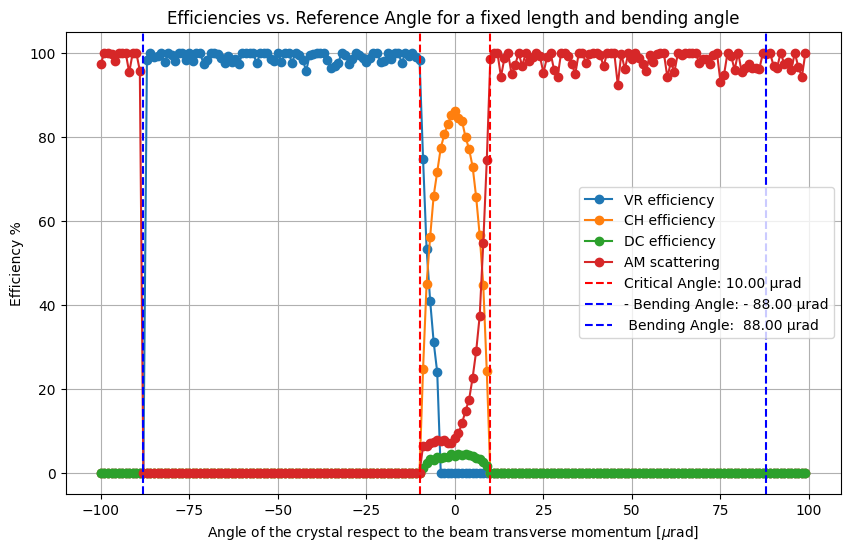

In [12]:
# Ensure efficiencies and bending angles are in the same order
efficiency_dataVR['bending_angle'] = [angle for angle in impacting_angles]  
efficiency_dataCH['bending_angle'] = [angle for angle in impacting_angles]  
efficiency_dataAM['bending_angle'] = [angle for angle in impacting_angles]  
efficiency_dataDC['bending_angle'] = [angle for angle in impacting_angles]  
efficiency_dataVC['bending_angle'] = [angle for angle in impacting_angles]  





# Plot Volume Reflection Efficiency vs Bending Angle
plt.figure(figsize=(10, 6))
plt.plot(efficiency_dataVR['bending_angle']*1.e6, efficiency_dataVR['efficiency'], marker='o', linestyle='-', label = 'VR efficiency')
plt.plot(efficiency_dataCH['bending_angle']*1.e6, efficiency_dataCH['efficiency'], marker='o', linestyle='-', label = 'CH efficiency')
plt.plot(efficiency_dataDC['bending_angle']*1.e6, efficiency_dataDC['efficiency'], marker='o', linestyle='-', label = 'DC efficiency')
#plt.plot(efficiency_dataVC['bending_angle']*1.e6, efficiency_dataVC['efficiency'], marker='o', linestyle='-', label = 'VC efficiency')


plt.plot(efficiency_dataAM['bending_angle']*1.e6, efficiency_dataAM['efficiency'], marker='o', linestyle='-', label = 'AM scattering')



#plt.plot(efficiency_dataAM['bending_angle']*1.e6, efficiency_dataAM['efficiency'] + efficiency_dataCH['efficiency'] + efficiency_dataVR['efficiency'] + efficienciesDC, marker='o', linestyle='-', label = 'Check')


# Add a vertical line for the critical angle
plt.axvline(x = critical_angle, color='red', linestyle='--', label=f'Critical Angle: {critical_angle:.2f} µrad')
# Add a vertical line for the critical angle
plt.axvline(x= - critical_angle, color='red', linestyle='--')
plt.axvline(x = - BendingAngle,  color = 'blue',linestyle='--', label=f'- Bending Angle: - {BendingAngle:.2f} µrad')
plt.axvline(x =  BendingAngle,  color = 'blue',linestyle='--', label=f' Bending Angle:  {BendingAngle:.2f} µrad')



# Customize the plot
plt.title('Efficiencies vs. Reference Angle for a fixed length and bending angle')
plt.xlabel(r'Angle of the crystal respect to the beam transverse momentum [$\mu$rad]')
plt.ylabel('Efficiency %')
plt.legend()
plt.grid(True)
plt.show()